In [1]:
!pip install pyroomacoustics librosa soundfile pandas matplotlib

In [2]:
import os
import shutil
import numpy as np
import pandas as pd
import soundfile as sf
import librosa
import matplotlib.pyplot as plt
import pyroomacoustics as pra

In [3]:
base_dir = "/Users/xuyixuan/Desktop/synthetic_brir_LR_840"

candidate_audio_dir = os.path.join(base_dir, "candidate_audio")
candidate_feature_dir = os.path.join(base_dir, "candidate_features")

final_audio_dir = os.path.join(base_dir, "audio")
final_feature_dir = os.path.join(base_dir, "features")

for d in [candidate_audio_dir, candidate_feature_dir, final_audio_dir, final_feature_dir]:
    os.makedirs(d, exist_ok=True)

print("Dataset folder:", base_dir)

Dataset folder: /Users/xuyixuan/Desktop/synthetic_brir_LR_840


In [4]:
sr = 44100
rir_length = 0.5
max_order = 10
ear_distance = 0.18

rooms = [
    [6.0, 4.0, 3.0],
    [8.0, 5.0, 3.0],
    [9.0, 6.0, 3.0],
    [10.0, 7.0, 3.0],
]

absorptions = [0.1, 0.2, 0.35, 0.5, 0.65, 0.8]

source_positions = [
    [1.0, 1.2, 1.5],
    [1.0, 2.0, 1.5],
    [1.0, 3.0, 1.5],
    [2.0, 1.5, 1.5],
    [2.0, 2.5, 1.5],
    [3.0, 2.0, 1.5],
]

listener_positions = [
    [1.5, 1.3, 1.5],
    [2.0, 1.3, 1.5],
    [2.5, 1.3, 1.5],
    [3.0, 1.3, 1.5],
    [3.5, 1.3, 1.5],
    [4.0, 1.3, 1.5],
    [4.5, 1.3, 1.5],

    [1.5, 2.5, 1.5],
    [2.0, 2.5, 1.5],
    [2.5, 2.5, 1.5],
    [3.0, 2.5, 1.5],
    [3.5, 2.5, 1.5],
    [4.0, 2.5, 1.5],
    [4.5, 2.5, 1.5],

    [1.5, 3.2, 1.5],
    [2.0, 3.2, 1.5],
    [2.5, 3.2, 1.5],
    [3.0, 3.2, 1.5],
    [3.5, 3.2, 1.5],
    [4.0, 3.2, 1.5],
]

expected_candidates = len(rooms) * len(absorptions) * len(source_positions) * len(listener_positions)
print("Expected candidate samples:", expected_candidates)

Expected candidate samples: 2880


In [5]:
def is_position_inside_room(pos, room_dim, margin=0.2):
    x, y, z = pos
    return (
        margin <= x <= room_dim[0] - margin and
        margin <= y <= room_dim[1] - margin and
        margin <= z <= room_dim[2] - margin
    )


def brir_to_logmel(brir, sr=44100, n_mels=64, n_fft=2048, hop_length=512):
    features = []

    for ch in range(2):
        mel = librosa.feature.melspectrogram(
            y=brir[ch],
            sr=sr,
            n_fft=n_fft,
            hop_length=hop_length,
            n_mels=n_mels
        )
        logmel = librosa.power_to_db(mel + 1e-12)
        features.append(logmel)

    return np.stack(features, axis=0).transpose(0, 2, 1).astype(np.float32)


def compute_c80(ir, sr):
    energy = ir ** 2
    split = int(0.08 * sr)

    early = np.sum(energy[:split])
    late = np.sum(energy[split:])

    return 10 * np.log10((early + 1e-12) / (late + 1e-12))


def compute_drr_peak(ir, sr, direct_ms=2.5):
    energy = ir ** 2
    peak_idx = np.argmax(np.abs(ir))

    half_win = int((direct_ms / 1000.0) * sr / 2)
    start = max(0, peak_idx - half_win)
    end = min(len(ir), peak_idx + half_win)

    direct = np.sum(energy[start:end])
    reverb = np.sum(energy) - direct

    return 10 * np.log10((direct + 1e-12) / (reverb + 1e-12))


def compute_ild(brir):
    left = brir[0]
    right = brir[1]

    left_rms = np.sqrt(np.mean(left ** 2))
    right_rms = np.sqrt(np.mean(right ** 2))

    return 20 * np.log10((left_rms + 1e-12) / (right_rms + 1e-12))


def compute_itd_peak(brir, sr):
    left_peak = np.argmax(np.abs(brir[0]))
    right_peak = np.argmax(np.abs(brir[1]))

    return (left_peak - right_peak) / sr * 1000

In [6]:
rows = []
idx = 0
target_len = int(rir_length * sr)

for room_id, room_dim in enumerate(rooms):
    for absorption in absorptions:
        V = room_dim[0] * room_dim[1] * room_dim[2]
        S = 2 * (
            room_dim[0] * room_dim[1]
            + room_dim[0] * room_dim[2]
            + room_dim[1] * room_dim[2]
        )
        rt60 = 0.161 * V / (absorption * S)

        for source_id, source_pos in enumerate(source_positions):
            if not is_position_inside_room(source_pos, room_dim):
                continue

            for listener_id, listener_center in enumerate(listener_positions):
                if not is_position_inside_room(listener_center, room_dim):
                    continue

                listener_center = np.array(listener_center)

                left_ear = listener_center + np.array([0, -ear_distance / 2, 0])
                right_ear = listener_center + np.array([0, ear_distance / 2, 0])

                if not is_position_inside_room(left_ear, room_dim):
                    continue
                if not is_position_inside_room(right_ear, room_dim):
                    continue

                mic_positions = np.c_[left_ear, right_ear]

                room = pra.ShoeBox(
                    room_dim,
                    fs=sr,
                    materials=pra.Material(absorption),
                    max_order=max_order
                )

                room.add_source(source_pos)
                room.add_microphone_array(pra.MicrophoneArray(mic_positions, room.fs))
                room.compute_rir()

                left_rir = librosa.util.fix_length(room.rir[0][0], size=target_len)
                right_rir = librosa.util.fix_length(room.rir[1][0], size=target_len)

                brir = np.stack([left_rir, right_rir], axis=0)
                mono_ir = (brir[0] + brir[1]) / 2.0

                drr = compute_drr_peak(mono_ir, sr)
                c80 = compute_c80(mono_ir, sr)
                ild = compute_ild(brir)
                itd = compute_itd_peak(brir, sr)

                wav_name = f"candidate_{idx:05d}.wav"
                npy_name = f"candidate_{idx:05d}.npy"

                wav_path = os.path.join(candidate_audio_dir, wav_name)
                npy_path = os.path.join(candidate_feature_dir, npy_name)

                sf.write(wav_path, brir.T, sr)

                feature = brir_to_logmel(brir, sr=sr)
                np.save(npy_path, feature)

                rows.append({
                    "candidate_id": idx,
                    "filename": wav_name,
                    "feature_file": npy_name,

                    "room_id": room_id,
                    "room_x": room_dim[0],
                    "room_y": room_dim[1],
                    "room_z": room_dim[2],

                    "absorption": absorption,
                    "RT60": rt60,

                    "source_id": source_id,
                    "source_x": source_pos[0],
                    "source_y": source_pos[1],
                    "source_z": source_pos[2],

                    "listener_id": listener_id,
                    "listener_x": listener_center[0],
                    "listener_y": listener_center[1],
                    "listener_z": listener_center[2],

                    "DRR": drr,
                    "C80": c80,
                    "ILD": ild,
                    "ITD_ms": itd,
                })

                idx += 1

df = pd.DataFrame(rows)

print("Candidate samples:", len(df))
print(df.head())

Candidate samples: 2880
   candidate_id             filename         feature_file  room_id  room_x  \
0             0  candidate_00000.wav  candidate_00000.npy        0     6.0   
1             1  candidate_00001.wav  candidate_00001.npy        0     6.0   
2             2  candidate_00002.wav  candidate_00002.npy        0     6.0   
3             3  candidate_00003.wav  candidate_00003.npy        0     6.0   
4             4  candidate_00004.wav  candidate_00004.npy        0     6.0   

   room_y  room_z  absorption      RT60  source_id  ...  source_y  source_z  \
0     4.0     3.0         0.1  1.073333          0  ...       1.2       1.5   
1     4.0     3.0         0.1  1.073333          0  ...       1.2       1.5   
2     4.0     3.0         0.1  1.073333          0  ...       1.2       1.5   
3     4.0     3.0         0.1  1.073333          0  ...       1.2       1.5   
4     4.0     3.0         0.1  1.073333          0  ...       1.2       1.5   

   listener_id  listener_x  list

In [7]:
q1 = df["DRR"].quantile(1/3)
q2 = df["DRR"].quantile(2/3)

def drr_to_class(x):
    if x < q1:
        return 0
    elif x < q2:
        return 1
    else:
        return 2

df["DRR_class"] = df["DRR"].apply(drr_to_class)

print("DRR thresholds:")
print("Class 0: DRR <", q1)
print("Class 1:", q1, "<= DRR <", q2)
print("Class 2: DRR >=", q2)

print("\nCandidate class counts:")
print(df["DRR_class"].value_counts().sort_index())

DRR thresholds:
Class 0: DRR < -5.760471030858143
Class 1: -5.760471030858143 <= DRR < 0.37666435646221147
Class 2: DRR >= 0.37666435646221147

Candidate class counts:
DRR_class
0    960
1    960
2    960
Name: count, dtype: int64


In [8]:
samples_per_class = 280

balanced_df = (
    df.groupby("DRR_class", group_keys=False)
      .apply(lambda x: x.sample(n=samples_per_class, random_state=42))
      .reset_index(drop=True)
)

print("Balanced class counts:")
print(balanced_df["DRR_class"].value_counts().sort_index())
print("Total balanced samples:", len(balanced_df))

Balanced class counts:
DRR_class
0    280
1    280
2    280
Name: count, dtype: int64
Total balanced samples: 840


/var/folders/54/ct0frh755j3ftw0stm_sbwh80000gn/T/ipykernel_22225/4091372159.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=samples_per_class, random_state=42))


In [9]:
final_rows = []

for new_idx, row in balanced_df.iterrows():
    base_name = f"{new_idx:04d}"

    left_name = f"{base_name}_L.wav"
    right_name = f"{base_name}_R.wav"
    feature_name = f"{base_name}.npy"

    old_wav_path = os.path.join(candidate_audio_dir, row["filename"])
    old_npy_path = os.path.join(candidate_feature_dir, row["feature_file"])

    audio, fs = sf.read(old_wav_path)

    if audio.ndim != 2 or audio.shape[1] != 2:
        raise ValueError(f"Expected stereo audio, but got shape {audio.shape}")

    left_audio = audio[:, 0]
    right_audio = audio[:, 1]

    sf.write(os.path.join(final_audio_dir, left_name), left_audio, sr)
    sf.write(os.path.join(final_audio_dir, right_name), right_audio, sr)

    shutil.copy(old_npy_path, os.path.join(final_feature_dir, feature_name))

    final_rows.append({
        "id": base_name,
        "left_file": left_name,
        "right_file": right_name,
        "feature_file": feature_name,

        "DRR_class": row["DRR_class"],
        "DRR": row["DRR"],
        "C80": row["C80"],
        "RT60": row["RT60"],
        "ILD": row["ILD"],
        "ITD_ms": row["ITD_ms"],

        "room_id": row["room_id"],
        "room_x": row["room_x"],
        "room_y": row["room_y"],
        "room_z": row["room_z"],

        "absorption": row["absorption"],

        "source_id": row["source_id"],
        "source_x": row["source_x"],
        "source_y": row["source_y"],
        "source_z": row["source_z"],

        "listener_id": row["listener_id"],
        "listener_x": row["listener_x"],
        "listener_y": row["listener_y"],
        "listener_z": row["listener_z"],
    })

final_df = pd.DataFrame(final_rows)

labels_path = os.path.join(base_dir, "labels.csv")
final_df.to_csv(labels_path, index=False)

print("Final labels saved:", labels_path)
print("Final samples:", len(final_df))
print(final_df.head())

Final labels saved: /Users/xuyixuan/Desktop/synthetic_brir_LR_840/labels.csv
Final samples: 840
     id   left_file  right_file feature_file  DRR_class       DRR        C80  \
0  0000  0000_L.wav  0000_R.wav     0000.npy          0 -8.614383   5.986164   
1  0001  0001_L.wav  0001_R.wav     0001.npy          0 -6.514824  15.473304   
2  0002  0002_L.wav  0002_R.wav     0002.npy          0 -6.459279   8.541361   
3  0003  0003_L.wav  0003_R.wav     0003.npy          0 -7.899700   8.356640   
4  0004  0004_L.wav  0004_R.wav     0004.npy          0 -5.965284  11.452064   

       RT60       ILD    ITD_ms  ...  room_z  absorption  source_id  source_x  \
0  1.397107 -0.043173  0.226757  ...     3.0        0.10          5       3.0   
1  0.349367  0.207192 -0.476190  ...     3.0        0.35          0       1.0   
2  1.222785  0.159370 -0.476190  ...     3.0        0.10          3       2.0   
3  0.698554 -0.100752 -0.022676  ...     3.0        0.20          2       1.0   
4  0.399174  0.063

In [10]:
audio_files = [f for f in os.listdir(final_audio_dir) if f.endswith(".wav")]
feature_files = [f for f in os.listdir(final_feature_dir) if f.endswith(".npy")]

print("Final audio files:", len(audio_files))
print("Final audio pairs:", len(audio_files) // 2)
print("Final feature files:", len(feature_files))
print("Final CSV rows:", len(final_df))

print("\nFinal DRR class counts:")
print(final_df["DRR_class"].value_counts().sort_index())

Final audio files: 1680
Final audio pairs: 840
Final feature files: 840
Final CSV rows: 840

Final DRR class counts:
DRR_class
0    280
1    280
2    280
Name: count, dtype: int64


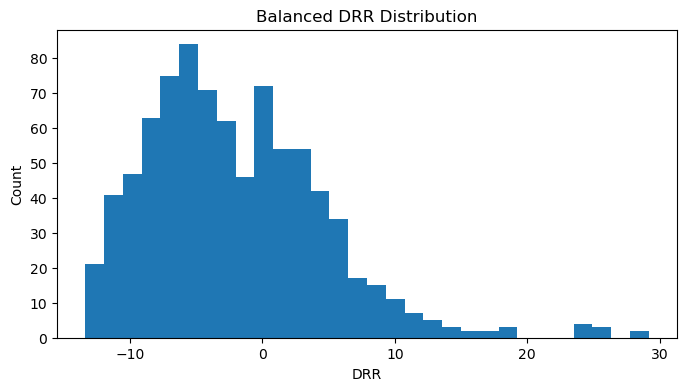

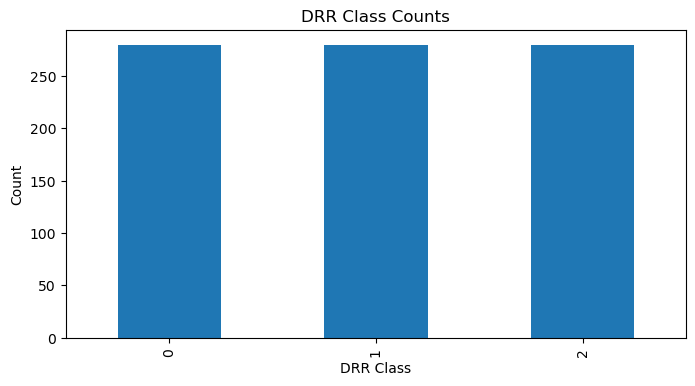

In [11]:
plt.figure(figsize=(8, 4))
plt.hist(final_df["DRR"], bins=30)
plt.title("Balanced DRR Distribution")
plt.xlabel("DRR")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8, 4))
final_df["DRR_class"].value_counts().sort_index().plot(kind="bar")
plt.title("DRR Class Counts")
plt.xlabel("DRR Class")
plt.ylabel("Count")
plt.show()

Left shape: (22050,)
Right shape: (22050,)
Left sample rate: 44100
Right sample rate: 44100
Feature shape: (2, 44, 64)


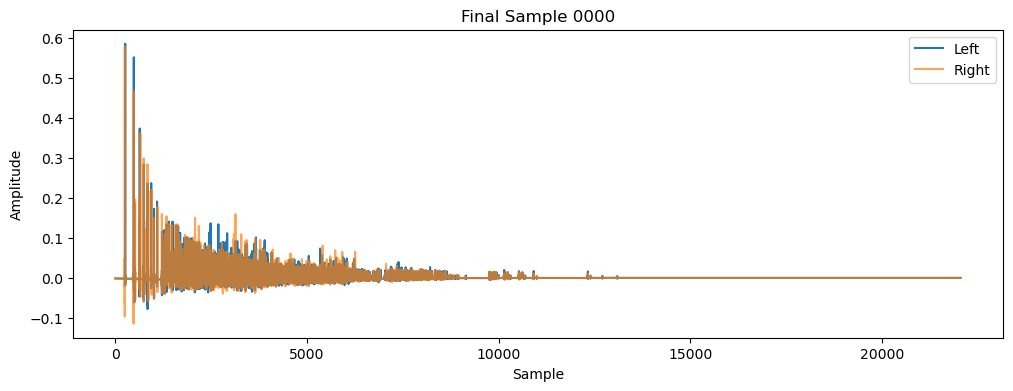

In [12]:
test_left_path = os.path.join(final_audio_dir, "0000_L.wav")
test_right_path = os.path.join(final_audio_dir, "0000_R.wav")
test_npy_path = os.path.join(final_feature_dir, "0000.npy")

left, fs_l = sf.read(test_left_path)
right, fs_r = sf.read(test_right_path)
feature = np.load(test_npy_path)

print("Left shape:", left.shape)
print("Right shape:", right.shape)
print("Left sample rate:", fs_l)
print("Right sample rate:", fs_r)
print("Feature shape:", feature.shape)

plt.figure(figsize=(12, 4))
plt.plot(left, label="Left")
plt.plot(right, label="Right", alpha=0.7)
plt.title("Final Sample 0000")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

In [13]:
def balanced_split_by_class(df, label_col="DRR_class", random_state=42):
    train_parts = []
    val_parts = []
    test_parts = []

    # target counts for each class
    train_counts = {0: 167, 1: 167, 2: 166}
    val_counts = {0: 67, 1: 67, 2: 66}
    test_counts = {0: 46, 1: 46, 2: 48}

    for cls in sorted(df[label_col].unique()):
        cls_df = df[df[label_col] == cls].sample(frac=1, random_state=random_state).reset_index(drop=True)

        n_train = train_counts[cls]
        n_val = val_counts[cls]
        n_test = test_counts[cls]

        train_parts.append(cls_df.iloc[:n_train])
        val_parts.append(cls_df.iloc[n_train:n_train + n_val])
        test_parts.append(cls_df.iloc[n_train + n_val:n_train + n_val + n_test])

    train_df = pd.concat(train_parts).sample(frac=1, random_state=random_state).reset_index(drop=True)
    val_df = pd.concat(val_parts).sample(frac=1, random_state=random_state).reset_index(drop=True)
    test_df = pd.concat(test_parts).sample(frac=1, random_state=random_state).reset_index(drop=True)

    train_df["split"] = "train"
    val_df["split"] = "validation"
    test_df["split"] = "test"

    return train_df, val_df, test_df


train_df, val_df, test_df = balanced_split_by_class(final_df)

train_df.to_csv(os.path.join(base_dir, "train_labels.csv"), index=False)
val_df.to_csv(os.path.join(base_dir, "validation_labels.csv"), index=False)
test_df.to_csv(os.path.join(base_dir, "test_labels.csv"), index=False)

all_split_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
all_split_df.to_csv(os.path.join(base_dir, "labels_with_split.csv"), index=False)

print("Train:", len(train_df))
print(train_df["DRR_class"].value_counts().sort_index())

print("\nValidation:", len(val_df))
print(val_df["DRR_class"].value_counts().sort_index())

print("\nTest:", len(test_df))
print(test_df["DRR_class"].value_counts().sort_index())

Train: 500
DRR_class
0    167
1    167
2    166
Name: count, dtype: int64

Validation: 200
DRR_class
0    67
1    67
2    66
Name: count, dtype: int64

Test: 140
DRR_class
0    46
1    46
2    48
Name: count, dtype: int64


In [14]:
import os
import shutil

split_dfs = {
    "train": train_df,
    "validation": val_df,
    "test": test_df
}

for split_name, split_data in split_dfs.items():
    for _, row in split_data.iterrows():
        cls = int(row["DRR_class"])
        class_folder = f"class_{cls}"

        dst_audio_dir = os.path.join(base_dir, "audio", split_name, class_folder)
        dst_feature_dir = os.path.join(base_dir, "features", split_name, class_folder)

        os.makedirs(dst_audio_dir, exist_ok=True)
        os.makedirs(dst_feature_dir, exist_ok=True)

        shutil.copy2(
            os.path.join(final_audio_dir, row["left_file"]),
            os.path.join(dst_audio_dir, row["left_file"])
        )

        shutil.copy2(
            os.path.join(final_audio_dir, row["right_file"]),
            os.path.join(dst_audio_dir, row["right_file"])
        )

        shutil.copy2(
            os.path.join(final_feature_dir, row["feature_file"]),
            os.path.join(dst_feature_dir, row["feature_file"])
        )

print("Done. Files are organized by split and class.")

Done. Files are organized by split and class.
